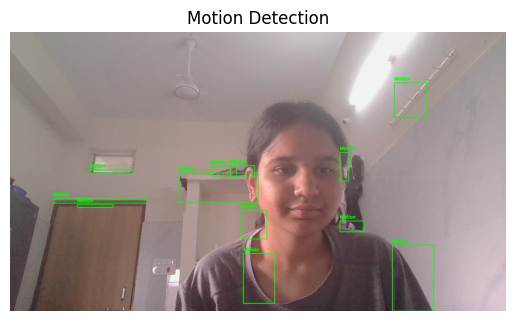

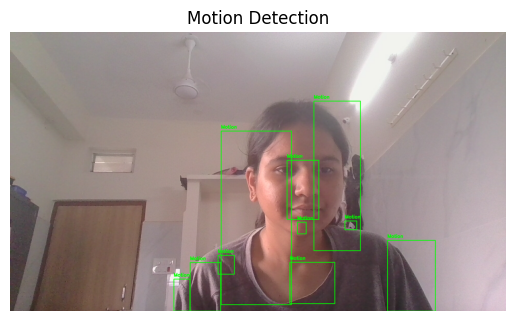

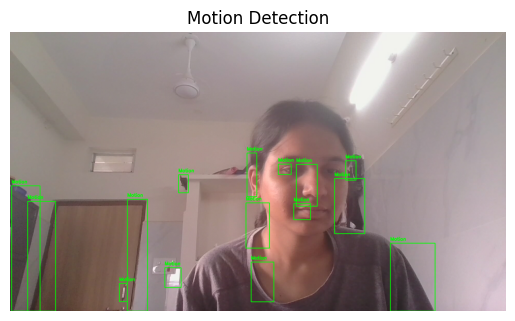

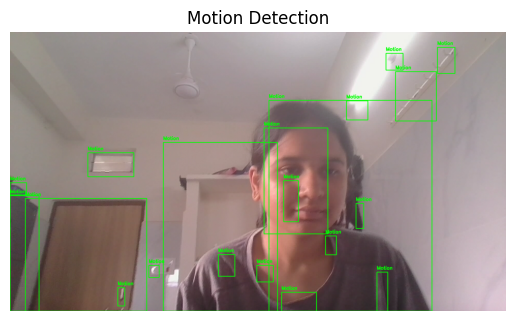

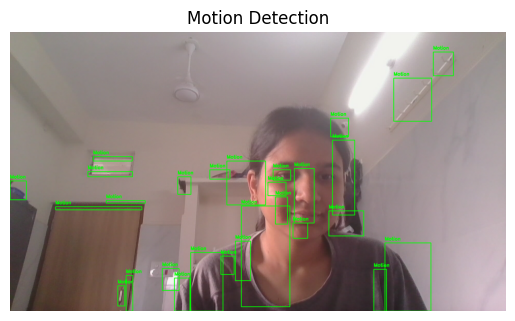

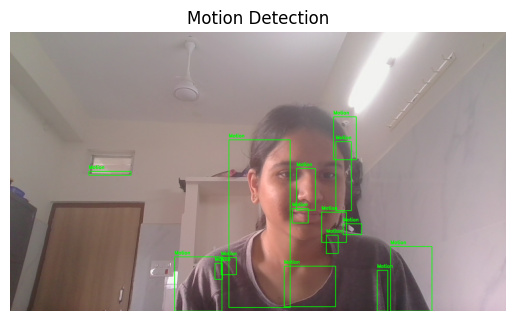

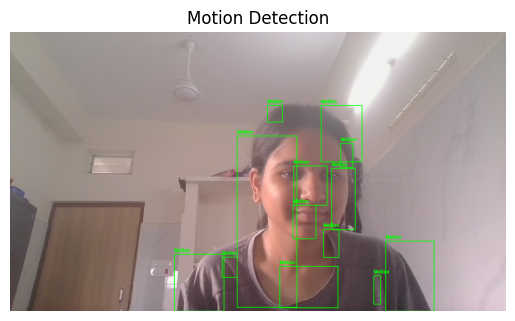

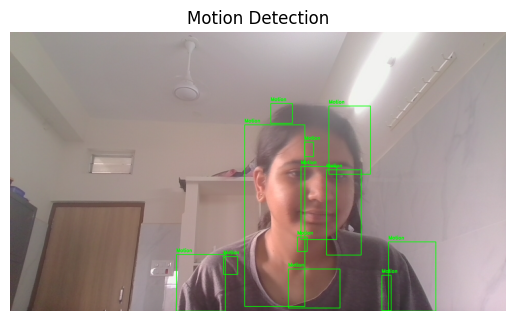

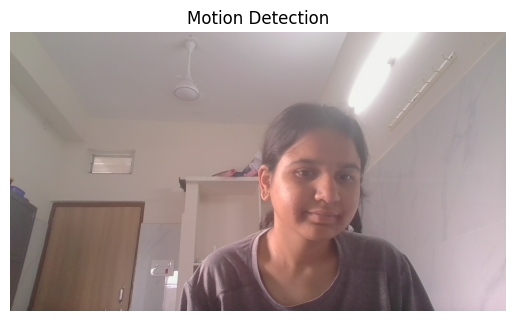

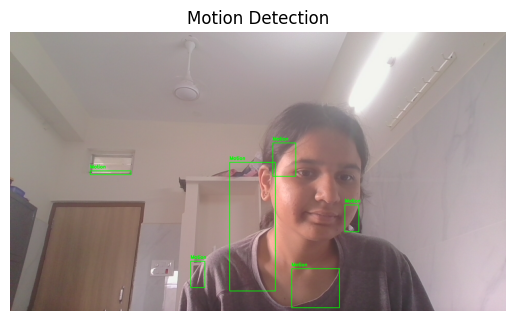

In [3]:
import cv2
import matplotlib.pyplot as plt

# Open webcam
cap = cv2.VideoCapture(0)

# Read first frames
ret, frame1 = cap.read()
ret, frame2 = cap.read()

# Run for few frames only (Jupyter limitation)
for i in range(10):

    # Motion detection
    diff = cv2.absdiff(frame1, frame2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)
    dilated = cv2.dilate(thresh, None, iterations=3)

    contours, _ = cv2.findContours(
        dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:
        if cv2.contourArea(contour) < 1000:
            continue

        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(frame1, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame1, "Motion", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    # Convert BGR → RGB for Jupyter display
    rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)

    plt.imshow(rgb)
    plt.axis("off")
    plt.title("Motion Detection")
    plt.show()

    # update frames
    frame1 = frame2
    ret, frame2 = cap.read()

cap.release()